In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
from pathlib import Path
import numpy as np

# Directory paths for train, validation, and test sets
dataset = Path('/content/drive/MyDrive/Bone_Fracture_Dataset')
train_dir = '/content/drive/MyDrive/Bone_Fracture_Dataset/train'
val_dir = '/content/drive/MyDrive/Bone_Fracture_Dataset/val'
test_dir = '/content/drive/MyDrive/Bone_Fracture_Dataset/test'

# Image dimensions
img_height = 224
img_width = 224
RANDOM_SEED = 42

In [ ]:
from PIL import Image
import os

def deep_clean_images(folder):
    bad_files = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                path = os.path.join(root, f)
                try:
                    with Image.open(path) as img:
                        img.load()  # 🔥 PAKSA LOAD PIXEL
                except Exception as e:
                    bad_files.append(path)

    print(f"❌ Total file rusak ditemukan: {len(bad_files)}")
    for bf in bad_files:
        print("HAPUS:", bf)
        os.remove(bf)

# JALANKAN KE SEMUA SPLIT
deep_clean_images(train_dir)
deep_clean_images(val_dir)
deep_clean_images(test_dir)

In [ ]:
# Image dimensions
img_height = 224
img_width = 224
RANDOM_SEED = 42
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.convnext import preprocess_input

IMG_SIZE = 224

# Custom preprocessing function for MobileNetV2
def convnext_preprocess(img):
    return preprocess_input(img)  # Converts to [-1, 1]

# ImageDataGenerator for data augmentation and correct normalization
datagen = ImageDataGenerator(
    preprocessing_function=convnext_preprocess,  # Use convnext preprocessing
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
def walk_dir(dataset):
    for dirpath, dirnames, filenames in os.walk(dataset):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_dir(dataset)

There are 3 directories and 0 images in '/content/drive/MyDrive/Bone_Fracture_Dataset'.
There are 2 directories and 0 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/test'.
There are 0 directories and 239 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/test/fractured'.
There are 0 directories and 263 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/test/not fractured'.
There are 2 directories and 0 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/train'.
There are 0 directories and 4635 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/train/not fractured'.
There are 0 directories and 4607 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/train/fractured'.
There are 2 directories and 0 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/val'.
There are 0 directories and 487 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/val/not fractured'.
There are 0 directories and 338 images in '/content/drive/MyDrive/Bone_Fracture_Dataset/val/f

In [ ]:
import cv2
import numpy as np

def apply_clahe(image):
    if len(image.shape) == 3 and image.shape[2] == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image_gray)

array([[128, 111,  93, ...,  56,  65,  81],
       [134, 116,  99, ...,  54,  62,  81],
       [128, 122, 122, ...,  54,  62,  81],
       ...,
       [128, 115, 107, ...,  47,  63,  74],
       [133, 122, 111, ...,  52,  68,  78],
       [136, 130, 118, ...,  65,  71,  82]], dtype=uint8)
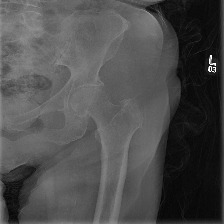

In [ ]:
IMG_SIZE = 224

def get_Image():
    image_path_list = list(dataset.glob("*/*/*.*"))
    sample_path = image_path_list[0]
    img = cv2.imread(str(sample_path))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = apply_clahe(img)
    return sample_path.name, img
_, img = get_Image()
img

<Figure size 1000x1000 with 0 Axes>

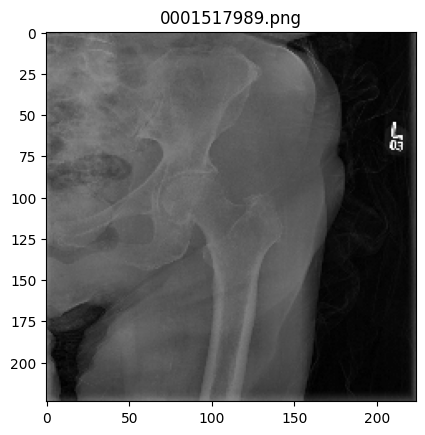

<Figure size 1000x1000 with 0 Axes>

In [ ]:
title, img = get_Image()
img_arr = np.asarray(img)

plt.imshow(img_arr, cmap='gray') #Always show black and white images
plt.title(title)
plt.figure(figsize=(10,10))

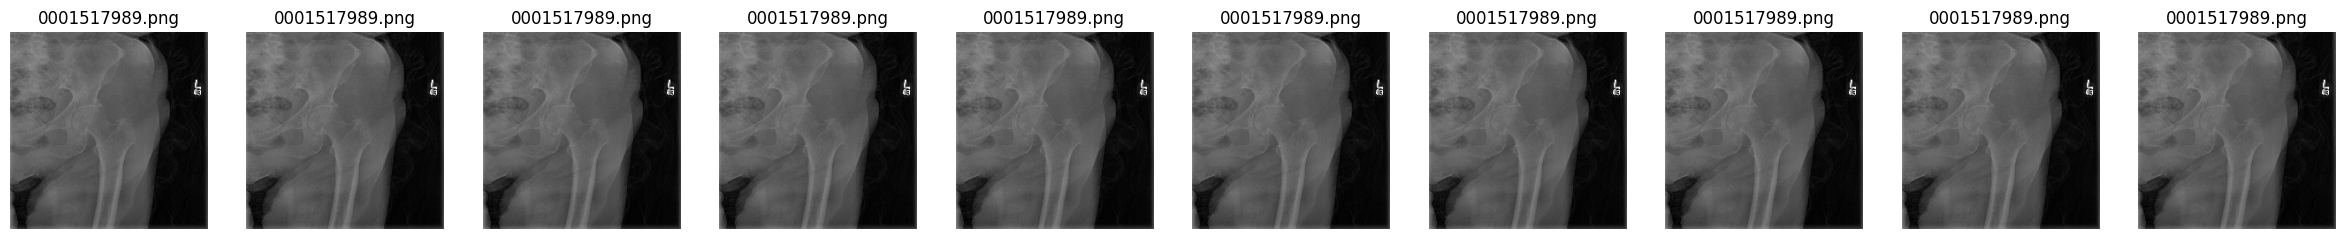

In [ ]:
def Show_Images(n_img):
    fig, axes = plt.subplots(1, n_img, figsize=(30, 20))
    axes = axes.flatten()  # Flatten axes for easy indexing

    # Loop through images and display them
    for i in range(n_img):
        title, img = get_Image()
        img = np.asarray(img)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(title)
        axes[i].axis("off")  # Hide axes
Show_Images(10)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 9240 images belonging to 2 classes.
Found 823 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout # Import necessary layers

base_model = ConvNeXtBase(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False # Bekukan seluruh model dasar

x = base_model.output
    # Gunakan GlobalAveragePooling2D seperti saran sebelumnya
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='gelu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) # Changed from Dense(2, ...) to Dense(1, ...)
model = Model(inputs=base_model.input, outputs=predictions)

learning_rate = 0.0001 # Tingkat pembelajaran yang sedikit lebih tinggi untuk fase ini
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])


    # Latih model selama beberapa epoch (misal 10-20 epoch)

r_frozen = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    verbose=2
)

350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


578/578 - 244s - 422ms/step - accuracy: 0.6129 - loss: 0.6617 - val_accuracy: 0.6343 - val_loss: 0.6327
Epoch 2/20
578/578 - 124s - 215ms/step - accuracy: 0.7018 - loss: 0.5638 - val_accuracy: 0.7570 - val_loss: 0.5276
Epoch 3/20
578/578 - 123s - 212ms/step - accuracy: 0.7372 - loss: 0.5181 - val_accuracy: 0.7728 - val_loss: 0.4861
Epoch 4/20
578/578 - 123s - 213ms/step - accuracy: 0.7521 - loss: 0.4961 - val_accuracy: 0.7752 - val_loss: 0.4892
Epoch 5/20
578/578 - 124s - 214ms/step - accuracy: 0.7715 - loss: 0.4694 - val_accuracy: 0.7813 - val_loss: 0.4879
Epoch 6/20
578/578 - 123s - 212ms/step - accuracy: 0.7794 - loss: 0.4525 - val_accuracy: 0.7837 - val_loss: 0.4851
Epoch 7/20
578/578 - 123s - 213ms/step - accuracy: 0.7820 - loss: 0.4445 - val_accuracy: 0.7910 - val_loss: 0.4450
Epoch 8/20
578/578 - 124s - 214ms/step - accuracy: 0.7897 - loss: 0.4305 - val_accuracy: 0.7874 - val_loss: 0.4317
Epoch 9/20
578/578 - 125s - 217ms/step - accuracy: 0.7979 - loss: 0.4178 - val_accuracy: 0.

In [ ]:
# Buka sebagian layer dari base_model
base_model.trainable = True
fine_tune_from = 50 # Sesuaikan nilai ini - Anda perlu mencari tahu berapa banyak layer terakhir yang ingin di-unfreeze
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False # Bekukan layer-layer awal

    # Kompilasi ulang model dengan learning rate yang sangat rendah
learning_rate = 0.00001 # Jauh lebih rendah!
optimizer = Adam(learning_rate=learning_rate) # Bisa juga gunakan optimizer lain seperti SGD dengan momentum
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Lanjutkan pelatihan selama lebih banyak epoch (misal 40-60 epoch lagi)
    # Anda bisa melanjutkan pelatihan dari bobot yang sudah dilatih di fase 1
r_fine_tune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=55,                     # total epoch
    initial_epoch=r_frozen.epoch[-1],  # lanjut dari epoch terakhir
    verbose=2
)

    # Anda bisa menggabungkan history dari kedua fase pelatihan untuk plotting

Epoch 20/25
578/578 - 255s - 441ms/step - accuracy: 0.9121 - loss: 0.2085 - val_accuracy: 0.9101 - val_loss: 0.2272
Epoch 21/25
578/578 - 128s - 221ms/step - accuracy: 0.9722 - loss: 0.0760 - val_accuracy: 0.9307 - val_loss: 0.1939
Epoch 22/25
578/578 - 127s - 220ms/step - accuracy: 0.9823 - loss: 0.0475 - val_accuracy: 0.9599 - val_loss: 0.1203
Epoch 23/25
578/578 - 128s - 221ms/step - accuracy: 0.9885 - loss: 0.0317 - val_accuracy: 0.9623 - val_loss: 0.0893
Epoch 24/25
578/578 - 128s - 221ms/step - accuracy: 0.9892 - loss: 0.0283 - val_accuracy: 0.9587 - val_loss: 0.1322
Epoch 25/25
578/578 - 127s - 220ms/step - accuracy: 0.9909 - loss: 0.0237 - val_accuracy: 0.9611 - val_loss: 0.0875


In [ ]:
import pandas as pd
#save history
# Use the variable where the history was actually stored, e.g., r_fine_tune
hist_df = pd.DataFrame(r_fine_tune.history)
# or save to csv:
hist_csv_file = 'model_convnext_new_history.csv'
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)

#save model
model.save("convnext_lung_fixed_ConvNeXtBase.keras")

#save weights
model.save_weights('model_convnext_new_lung_.weights.h5')

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import tensorflow as tf

# =========================
# LOAD MODEL
# =========================
model = tf.keras.models.load_model("/content/drive/MyDrive/Model/convnext_lung_fixed_ConvNeXtBase.keras")



# =========================
# AMBIL HISTORY
# =========================
# The training history is not part of the loaded model object.
# It was stored in the `r_fine_tune` variable during training.
# To plot the history, you should use the saved history.
# For example, if you saved the history to a CSV, you can load it here.
# For now, I'll use the r_fine_tune.history that is still in memory from the previous cells.
# history = model.history # This line caused the error
# history = r_fine_tune.history # Correctly use the saved history
epochs = range(1, len(history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history['loss'], label='Train Loss', marker='o')
plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

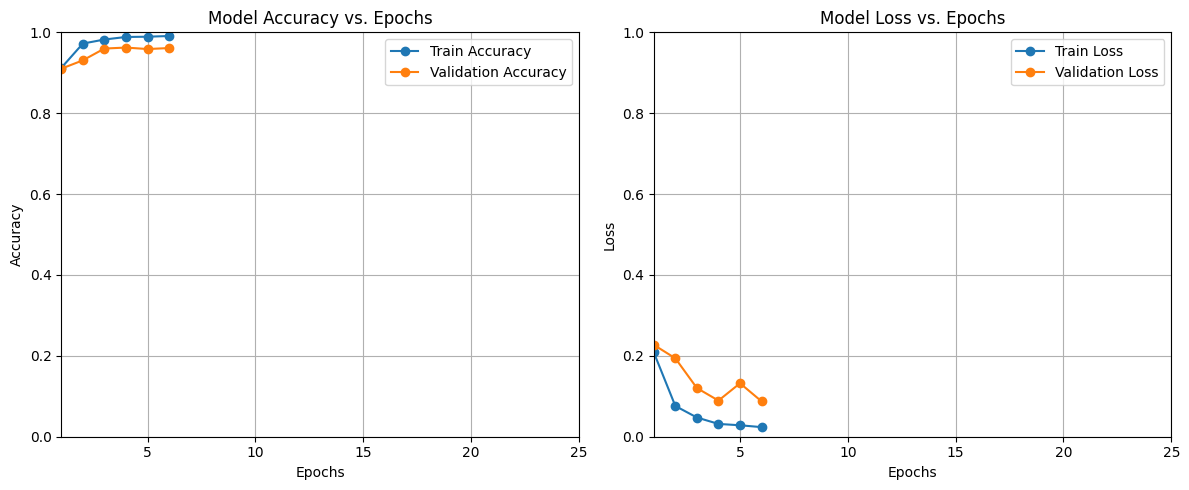

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'r_fine_tune.history' contains the training history
history = r_fine_tune.history

# Buat sumbu epoch sampai 70
epochs = range(1, 26)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs[:len(history['accuracy'])], history['accuracy'],
         label='Train Accuracy', marker='o')
plt.plot(epochs[:len(history['val_accuracy'])], history['val_accuracy'],
         label='Validation Accuracy', marker='o')
plt.title('Model Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)
plt.xlim(1, 25)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs[:len(history['loss'])], history['loss'],
         label='Train Loss', marker='o')
plt.plot(epochs[:len(history['val_loss'])], history['val_loss'],
         label='Validation Loss', marker='o')
plt.title('Model Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)
plt.xlim(1, 25)

plt.tight_layout()
plt.show()


Found 500 images belonging to 2 classes.
Class Labels: ['fractured', 'not fractured']
16/16 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step
Unique predictions: (array([0, 1]), array([498,   2]))

Overall Evaluation Metrics:


,Metric,Score
0,Accuracy,0.480000
1,Precision,1.000000
2,Recall,0.007634
3,F1-Score,0.015152



Classification Report:
               precision    recall  f1-score   support

    fractured     0.4779    1.0000    0.6467       238
not fractured     1.0000    0.0076    0.0152       262

     accuracy                         0.4800       500
    macro avg     0.7390    0.5038    0.3309       500
 weighted avg     0.7515    0.4800    0.3158       500



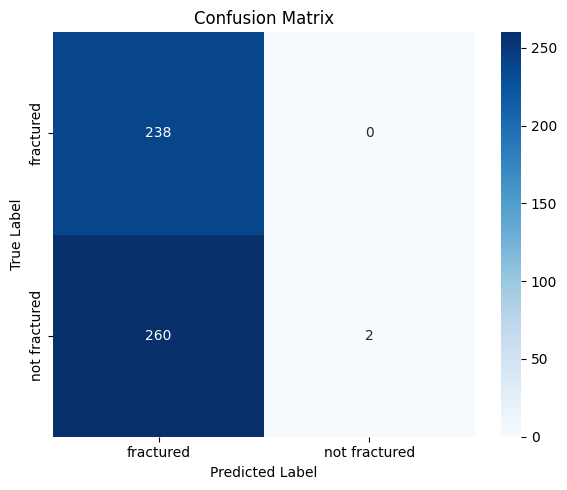

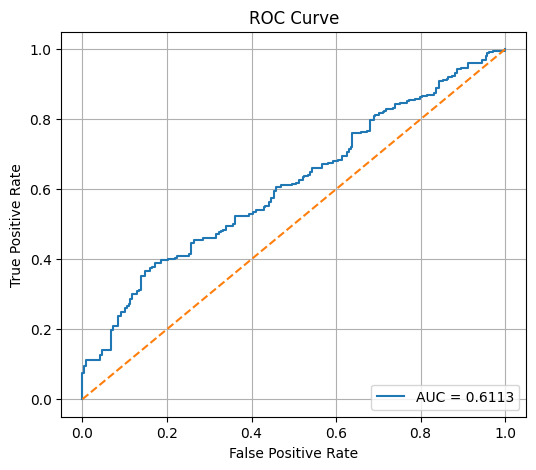

Optimal Threshold: 2.9768367e-07

Classification Report (Optimal Threshold):
               precision    recall  f1-score   support

    fractured     0.5501    0.8529    0.6689       238
not fractured     0.7328    0.3664    0.4885       262

     accuracy                         0.5980       500
    macro avg     0.6415    0.6097    0.5787       500
 weighted avg     0.6459    0.5980    0.5744       500



In [ ]:
# ===============================
# IMPORT LIBRARY
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ===============================
# 1. TEST DATA GENERATOR
# ===============================
test_datagen = ImageDataGenerator(
    preprocessing_function=convnext_preprocess
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    shuffle=False  # WAJIB agar urutan label benar
)

# ===============================
# 2. CLASS LABELS
# ===============================
class_labels = list(test_gen.class_indices.keys())
class_labels = [class_labels[i] for i in sorted(test_gen.class_indices.values())]

print("Class Labels:", class_labels)

# ===============================
# 3. PREDIKSI MODEL (PROBABILITAS)
# ===============================
y_prob = model.predict(
    test_gen,
    steps=len(test_gen),
    verbose=1
).ravel()  # shape (N,)

# ===============================
# 4. KONVERSI PROBABILITAS → LABEL
# ===============================
THRESHOLD = 0.5  # standar binary classification

y_pred = (y_prob >= THRESHOLD).astype(int)
y_true = test_gen.classes

# Debug cepat (opsional)
print("Unique predictions:", np.unique(y_pred, return_counts=True))

# ===============================
# 5. METRIK EVALUASI GLOBAL
# ===============================
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score":  [accuracy, precision, recall, f1]
})

print("\nOverall Evaluation Metrics:")
display(metrics_df)

# ===============================
# 6. CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        digits=4
    )
)

# ===============================
# 7. CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ===============================
# 8. ROC CURVE & AUC
# ===============================
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ===============================
# 9. (OPSIONAL) THRESHOLD OPTIMAL
# ===============================
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

# Prediksi ulang dengan threshold optimal
y_pred_opt = (y_prob >= optimal_threshold).astype(int)

print("\nClassification Report (Optimal Threshold):")
print(
    classification_report(
        y_true,
        y_pred_opt,
        target_names=class_labels,
        digits=4
    )
)

Model berhasil dimuat


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_pre… │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_stem │ (None, 56, 56,    │      9,792 │ convnext_large_p… │
│ (Sequential)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │      9,600 │ convnext_large_s… │
│ (Conv2D)            │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │        384 │ convnext_large_s… │
│ (LayerNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │    148,224 │ convnext_large_s… │
│ (Dense)             │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │          0 │ convnext_large_s… │
│ (Activation)        │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │    147,648 │ convnext_large_s… │
│ (Dense)             │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │        192 │ convnext_large_s… │
│ (LayerScale)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │          0 │ convnext_large_s… │
│ (Activation)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ convnext_large_s… │
│                     │ 192)              │            │ convnext_large_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │      9,600 │ add[0][0]         │
│ (Conv2D)            │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │        384 │ convnext_large_s… │
│ (LayerNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │    148,224 │ convnext_large_s… │
│ (Dense)             │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │          0 │ convnext_large_s… │
│ (Activation)        │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │    147,648 │ convnext_large_s… │
│ (Dense)             │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │        192 │ convnext_large_s

 Total params: 574,227,653 (2.14 GB)

 Trainable params: 188,604,929 (719.47 MB)

 Non-trainable params: 8,412,864 (32.09 MB)

 Optimizer params: 377,209,860 (1.41 GB)

Class indices : {'fractured': 0, 'not fractured': 1}


Saving 9-rotated3-rotated3-rotated2.jpg to 9-rotated3-rotated3-rotated2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Raw model output : 0.746653
Predicted index : 1


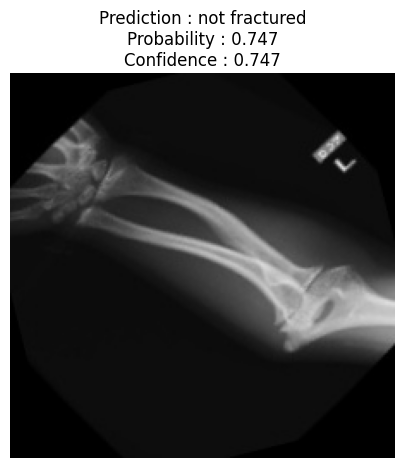

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


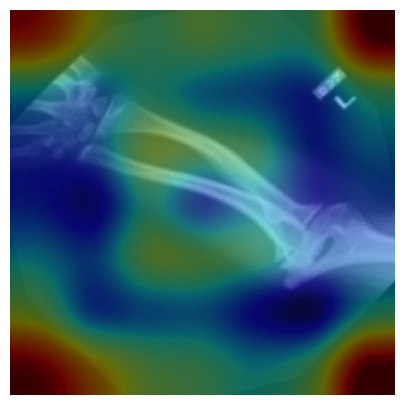

In [ ]:
# =========================================
# IMPORT LIBRARY
# =========================================
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# =========================================
# PARAMETER
# =========================================
IMG_SIZE = 224

# =========================================
# LOAD MODEL (.keras)
# =========================================
MODEL_PATH = "/content/drive/MyDrive/Model/convnext_lung_fixed_ConvNeXtBase.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model berhasil dimuat")
model.summary()

# =========================================
# PREPROCESSING (SAMA DENGAN TRAINING)
# =========================================
def preprocess_image(img_path, target_size=(224,224)):

    img = Image.open(img_path).convert('RGB')
    img = img.resize(target_size)

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = convnext_preprocess(img_array)

    return img_array


# =========================================
# PREDICTION FUNCTION
# =========================================
def predict_image_class(model, img_array, class_indices):

    prob = model.predict(img_array)[0][0]

    index_to_class = {v:k for k,v in class_indices.items()}

    if prob >= 0.5:
        predicted_index = 1
    else:
        predicted_index = 0

    predicted_class = index_to_class[predicted_index]

    confidence = prob if predicted_index==1 else 1-prob

    print("Raw model output :", prob)
    print("Predicted index :", predicted_index)

    return predicted_class, confidence, prob


# =========================================
# GRAD CAM
# =========================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap,0)

    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


# =========================================
# DISPLAY GRADCAM
# =========================================
def display_gradcam(img_path, heatmap, alpha=0.4):

    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

    heatmap = np.uint8(255 * heatmap)

    heatmap = Image.fromarray(heatmap).resize(img.size)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=alpha)
    plt.axis('off')
    plt.show()


# =========================================
# CEK LABEL DATASET
# =========================================
print("Class indices :", train_gen.class_indices)


# =========================================
# INFERENCE (UPLOAD GAMBAR)
# =========================================
uploaded = files.upload()

for fn in uploaded.keys():

    img_path = fn

    img_array = preprocess_image(img_path)

    predicted_class, confidence, prob = predict_image_class(
        model,
        img_array,
        train_gen.class_indices
    )

    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(
        f"Prediction : {predicted_class}\n"
        f"Probability : {prob:.3f}\n"
        f"Confidence : {confidence:.3f}"
    )
    plt.axis('off')
    plt.show()


    # =========================================
    # GRADCAM
    # =========================================
    last_conv_layer_name = [
        layer.name
        for layer in model.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ][-1]

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    display_gradcam(img_path, heatmap)

Model berhasil dimuat


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_pre… │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_stem │ (None, 56, 56,    │      9,792 │ convnext_large_p… │
│ (Sequential)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │      9,600 │ convnext_large_s… │
│ (Conv2D)            │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │        384 │ convnext_large_s… │
│ (LayerNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │    148,224 │ convnext_large_s… │
│ (Dense)             │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │          0 │ convnext_large_s… │
│ (Activation)        │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │    147,648 │ convnext_large_s… │
│ (Dense)             │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │        192 │ convnext_large_s… │
│ (LayerScale)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │          0 │ convnext_large_s… │
│ (Activation)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ convnext_large_s… │
│                     │ 192)              │            │ convnext_large_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │      9,600 │ add[0][0]         │
│ (Conv2D)            │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │        384 │ convnext_large_s… │
│ (LayerNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │    148,224 │ convnext_large_s… │
│ (Dense)             │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │          0 │ convnext_large_s… │
│ (Activation)        │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │    147,648 │ convnext_large_s… │
│ (Dense)             │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_large_sta… │ (None, 56, 56,    │        192 │ convnext_large_s

 Total params: 574,227,653 (2.14 GB)

 Trainable params: 188,604,929 (719.47 MB)

 Non-trainable params: 8,412,864 (32.09 MB)

 Optimizer params: 377,209,860 (1.41 GB)

Class indices : {'fractured': 0, 'not fractured': 1}


Saving 9-rotated3-rotated2.jpg to 9-rotated3-rotated2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Raw model output : 9.701726e-09
Predicted index : 0


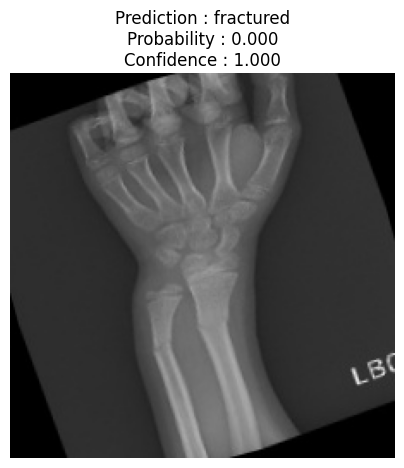

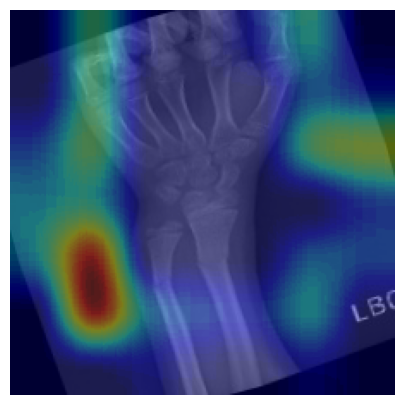

In [ ]:
# =========================================
# IMPORT LIBRARY
# =========================================
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# =========================================
# PARAMETER
# =========================================
IMG_SIZE = 224

# =========================================
# LOAD MODEL (.keras)
# =========================================
MODEL_PATH = "/content/drive/MyDrive/Model/convnext_lung_fixed_ConvNeXtBase.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model berhasil dimuat")
model.summary()

# =========================================
# PREPROCESSING (SAMA DENGAN TRAINING)
# =========================================
def preprocess_image(img_path, target_size=(224,224)):

    img = Image.open(img_path).convert('RGB')
    img = img.resize(target_size)

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = convnext_preprocess(img_array)

    return img_array


# =========================================
# PREDICTION FUNCTION
# =========================================
def predict_image_class(model, img_array, class_indices):

    prob = model.predict(img_array)[0][0]

    index_to_class = {v:k for k,v in class_indices.items()}

    if prob >= 0.5:
        predicted_index = 1
    else:
        predicted_index = 0

    predicted_class = index_to_class[predicted_index]

    confidence = prob if predicted_index==1 else 1-prob

    print("Raw model output :", prob)
    print("Predicted index :", predicted_index)

    return predicted_class, confidence, prob


# =========================================
# GRAD CAM
# =========================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap,0)

    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


# =========================================
# DISPLAY GRADCAM
# =========================================
def display_gradcam(img_path, heatmap, alpha=0.4):

    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

    heatmap = np.uint8(255 * heatmap)

    heatmap = Image.fromarray(heatmap).resize(img.size)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=alpha)
    plt.axis('off')
    plt.show()


# =========================================
# CEK LABEL DATASET
# =========================================
print("Class indices :", train_gen.class_indices)


# =========================================
# INFERENCE (UPLOAD GAMBAR)
# =========================================
uploaded = files.upload()

for fn in uploaded.keys():

    img_path = fn

    img_array = preprocess_image(img_path)

    predicted_class, confidence, prob = predict_image_class(
        model,
        img_array,
        train_gen.class_indices
    )

    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(
        f"Prediction : {predicted_class}\n"
        f"Probability : {prob:.3f}\n"
        f"Confidence : {confidence:.3f}"
    )
    plt.axis('off')
    plt.show()


    # =========================================
    # GRADCAM
    # =========================================
    last_conv_layer_name = [
        layer.name
        for layer in model.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ][-1]

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    display_gradcam(img_path, heatmap)